# Customer Segmentation Project (K-Means)

Welcome to your customer segmentation pipeline! The goal of this project is to take raw customer data and use **K-Means Clustering** to discover hidden "personas" or groups of similar customers. This allows the business to launch highly targeted marketing campaigns.

### The Pipeline Steps:
1. **Data Loading & EDA**: Understanding what we are working with.
2. **Preprocessing**: Scaling numbers and handling text so K-Means can do math on them.
3. **Choosing K**: Using the Elbow Method to find the optimal number of personas.
4. **Clustering & Interpretation**: Running the algorithm and decoding the results to extract business value.


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load Data
df = pd.read_csv('customer_segmentation_data.csv')
print(f"Dataset Shape: {df.shape}\n")

# Display the first few rows
display(df.head())

# Let's check for missing values and data types
print("\nMissing Values:")
print(df.isnull().sum())


Dataset Shape: (1000, 9)



,id,age,gender,income,spending_score,membership_years,purchase_frequency,preferred_category,last_purchase_amount
0,1,38,Female,99342,90,3,24,Groceries,113.53
1,2,21,Female,78852,60,2,42,Sports,41.93
2,3,60,Female,126573,30,2,28,Clothing,424.36
3,4,40,Other,47099,74,9,5,Home & Garden,991.93
4,5,65,Female,140621,21,3,25,Electronics,347.08



Missing Values:
id                      0
age                     0
gender                  0
income                  0
spending_score          0
membership_years        0
purchase_frequency      0
preferred_category      0
last_purchase_amount    0
dtype: int64


## 2. Preprocessing

K-Means relies on **distance**. This means two things:
1. It cannot calculate the distance of text like "Female" or "Groceries". We must either encode them to numbers or drop them. For this numerical segmentation, we will drop the purely categorical features and the useless `id` column.
2. We **MUST scale** the data. Otherwise, a difference of $10,000 in `income` will completely overshadow a difference of 5 `membership_years`.


In [15]:
from sklearn.preprocessing import StandardScaler

# Drop ID (useless for math) and categorical variables for pure numerical clustering
# (Alternatively, you could One-Hot Encode them, but clustering on pure behavior/demographics is a strong start)
X_num = df[['age', 'income', 'spending_score', 'membership_years', 'purchase_frequency', 'last_purchase_amount']]

# Initialize the Scaler
scaler = StandardScaler()

# Fit and transform the numerical data
X_scaled = scaler.fit_transform(X_num)

# Convert back to a DataFrame just to see it
df_scaled = pd.DataFrame(X_scaled, columns=X_num.columns)
display(df_scaled.head())


conf = df_scaled.corr()
conf



,age,income,spending_score,membership_years,purchase_frequency,last_purchase_amount
0,-0.384644,0.316868,1.358468,-0.865010,-0.182348,-1.281540
1,-1.515362,-0.282016,0.321865,-1.215358,1.082005,-1.523763
2,1.078639,1.112778,-0.714738,-1.215358,0.098620,-0.230005
3,-0.251618,-1.210096,0.805613,1.237080,-1.516943,1.690080
4,1.411203,1.523374,-1.025718,-0.865010,-0.112106,-0.491443


,age,income,spending_score,membership_years,purchase_frequency,last_purchase_amount
age,1.000000,-0.000688,0.017707,-0.003431,-0.030137,0.061599
income,-0.000688,1.000000,0.000020,-0.035783,0.000533,-0.054006
spending_score,0.017707,0.000020,1.000000,0.026726,0.006708,-0.014475
membership_years,-0.003431,-0.035783,0.026726,1.000000,0.069532,-0.014135
purchase_frequency,-0.030137,0.000533,0.006708,0.069532,1.000000,0.024400
last_purchase_amount,0.061599,-0.054006,-0.014475,-0.014135,0.024400,1.000000


## 3. Choosing K (The Elbow Method)

We don't know how many customer segments exist. Let's run K-Means from $K=1$ to $K=10$ and plot the Inertia to find the "Elbow".


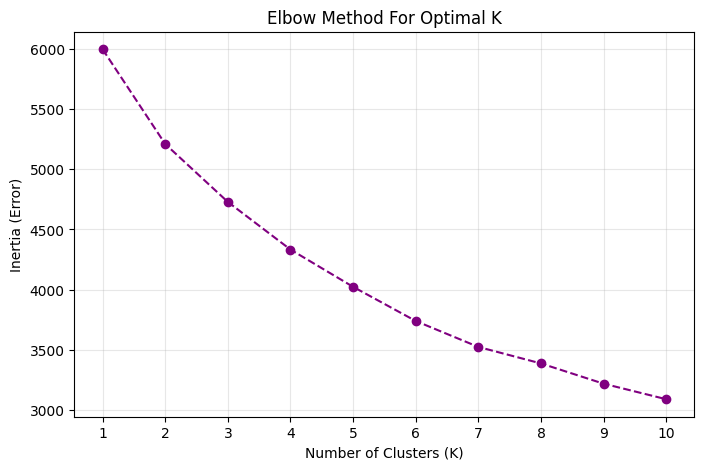

Look for the 'kink' or 'elbow' in the graph. It looks like K=4 or K=5 might be a good starting point!


In [4]:
from sklearn.cluster import KMeans

inertias = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K_range, inertias, marker='o', linestyle='--', color='purple')
plt.title('Elbow Method For Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia (Error)')
plt.xticks(K_range)
plt.grid(True, alpha=0.3)
plt.show()

print("Look for the 'kink' or 'elbow' in the graph. It looks like K=4 or K=5 might be a good starting point!")


## 4. Clustering & Interpretation

Let's proceed with **K=4** clusters. We will fit the algorithm, assign every customer a "Cluster ID", and then look at the *average* values of each cluster to figure out who these people are!


,age,income,spending_score,membership_years,purchase_frequency,last_purchase_amount
Cluster,,,,,,
0,44.4,80122.8,38.5,3.4,25.5,764.6
1,47.2,89898.9,66.0,8.3,32.1,673.0
2,43.0,93596.6,24.1,6.2,25.5,263.6
3,40.7,90352.9,77.5,4.1,23.6,284.8


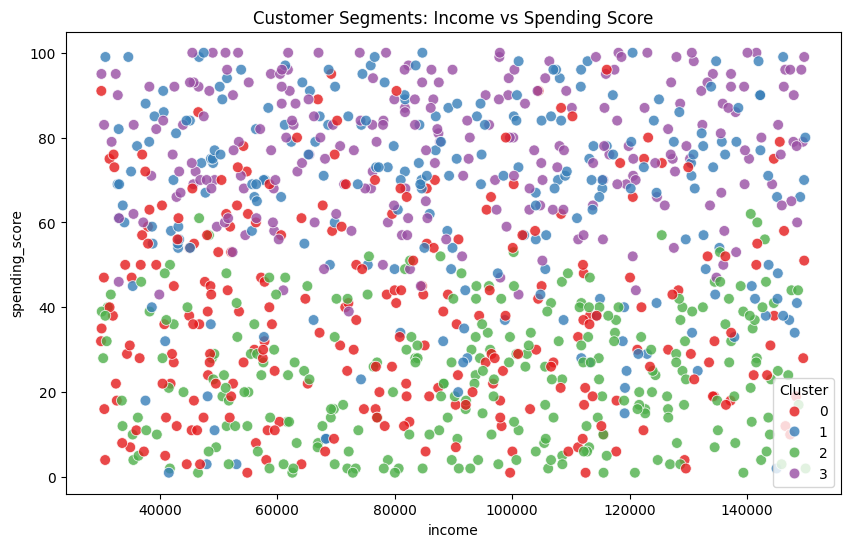

In [10]:
# 1. Fit the final model
optimal_k = 4
final_kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df['Cluster'] = final_kmeans.fit_predict(X_scaled)

# 2. Analyze the Clusters by taking the MEAN of the original, unscaled data
cluster_analysis = df.groupby('Cluster')[['age', 'income', 'spending_score', 'membership_years', 'purchase_frequency', 'last_purchase_amount']].mean()

# Round it to make it readable
display(cluster_analysis.round(1))

# Let's visualize a specific relationship: Income vs Spending Score
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='income', y='spending_score', hue='Cluster', palette='Set1', s=60, alpha=0.8)
plt.title("Customer Segments: Income vs Spending Score")
plt.show()
